# ExProf-Bench-T1: RuleShift
## Cognitive flexibility and rule-shift detection

**Kaggle AGI Hackathon 2026** | Track: Executive Functions | Google DeepMind × Kaggle

**Developed by:** Gerlyn Eduardo Duarte (Autism Spectrum Disorder [ASD] Researcher, Universidad de Los Andes | gerlyn@ula.ve)

---

### 1. Task summary
The **RuleShift** task tests cognitive flexibility by forcing the AI agent to follow a specific organizational rule (e.g. alphabetical sorting) and suddenly shift to a completely different implicit rule (e.g. reverse length sorting) midway through a stream of data without explicit warning.

### 2. Neuropsychological rationale
Based on the Wisconsin Card Sorting Test paradigm, failure to recognize the shifted pattern signifies an impairment in Set-Shifting / Cognitive Flexibility.

`Metric: TEI`

Provides the **TEI** component for the global EPI formula. TEI represents the proportion of items where the model perseverated on the previous rule. Being an error rate, a higher value indicates worse performance.

**Global Executive Performance Impairment (EPI):**
$$ EPI = \frac{TEI + PV + (1 - TSO) + (1 - IS) + TVR + \frac{ER + (1 - PD)}{2}}{6} $$

*Where:*
- **TEI**: Task-set Error Index (T1 - Cognitive Flexibility)
- **PV**: Protocol Violation rate (T2 - Inhibitory Control)
- **1 - TSO**: Impaired Task Sequence Optimization (T3 - Planning)
- **1 - IS**: Impaired Systematicity Index (T4 - Working Memory)
- **TVR**: Trail Violation Rate (T5 - Fluid Intelligence)
- **ER**: Spatial Error Rate / **PD**: Precision Degradation (T6 - Dual-Tasking)

*Direction:* 0 = no impairment (best), 1 = total failure (worst).

**Normative Anchor (EPI Range):**
- `< 0.20`: Healthy adult baseline (BRIEF-2A, n=1,637)
- `0.20 - 0.40`: Executive borderline zone
- `> 0.40`: Mild to severe executive dysfunction

### 3. Global passing criteria (>= 0.70 pass rate)
To achieve a passing metric and demonstrate analytical competence without an Executive Performance Impairment, the model must successfully process the items with an overall score greater than or equal to **70%**.





### 4. Mathematical Implementation
The algorithmic translation of this metric inside the evaluation loop filters specifically for `PERSEVERATION` traces within the agent's output. The local Impairment is isolated strictly mathematically as the proportion of these executive failures over the total item responses: `TEI = count(perseveration_errors) / total_items`.

In [1]:
import kaggle_benchmarks as kbench
import re, os, json, random, datetime
from collections import defaultdict, Counter
from datetime import date, timedelta

try:
    import matplotlib
except ImportError:
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, '-m', 'pip', 'install', 'matplotlib', '-q'])

GLOBAL_RESULTS_T1 = []

# Maps ef_obstacle labels → 6 standard EF dimensions (Miyake et al. 2000 / BRIEF-2A)
EF_DIMENSION_T1 = {
    'Working Memory':          'Working Memory',
    'Semantic Inhibition':     'Semantic Inhibition',
    'Look-Ahead Planning':     'Look-Ahead Planning',
    'Combined Executive Load': 'Combined Executive Load',
    'Inhibitory Control':      'Inhibitory Control',
    'Perseveration Monitoring':'Perseveration Monitoring',
}
EF_DIM_ORDER = [
    'Working Memory',
    'Semantic Inhibition',
    'Look-Ahead Planning',
    'Combined Executive Load',
    'Inhibitory Control',
    'Perseveration Monitoring',
]

DIFF_CONFIG = {
    'EASY': {
        'domain': 'customer_support', 'announcement_style': 'EXPLICIT',
        'ef_primary': 'Inhibitory Control', 'ef_obstacle': 'Working Memory',
        'ef_obstacle_description': '{n} phase1 examples load WM with rule_a pattern',
        'rule_a': {'criterion': 'submission_date', 'order': 'ASC',
                   'label': 'submission date (oldest first)'},
        'rule_b': {'criterion': 'impact_score', 'order': 'DESC',
                   'label': 'operational impact index (highest first)'},
        'n_phase1': 10, 'n_phase2': 3,
        'crit_a_type': 'date', 'crit_b_type': 'int', 'correlation': 'positive',
        'hide_crit_b_in_phase2': True,
    },
    'MEDIUM': {
        'domain': 'inventory_management', 'announcement_style': 'PARAGRAPH',
        'ef_primary': 'Inhibitory Control', 'ef_obstacle': 'Semantic Inhibition',
        'ef_obstacle_description': 'Item names semantically suggest priority but critical_value contradicts appearance',
        'rule_a': {'criterion': 'arrival_date', 'order': 'ASC',
                   'label': 'arrival date (oldest first)'},
        'rule_b': {'criterion': 'critical_value', 'order': 'DESC',
                   'label': 'restocking criticality index (highest first)'},
        'n_phase1': 12, 'n_phase2': 4,
        'crit_a_type': 'date', 'crit_b_type': 'int', 'correlation': 'positive',
        'hide_crit_b_in_phase2': False,   # semantic inhibition needs the visible number
    },
    'HARD': {
        'domain': 'clinical_scheduling', 'announcement_style': 'SUBORDINATE',
        'ef_primary': 'Cognitive Flexibility', 'ef_obstacle': 'Look-Ahead Planning',
        'ef_obstacle_description': 'Patient with most waiting_days has lowest clinical_urgency',
        'rule_a': {'criterion': 'waiting_days', 'order': 'DESC',
                   'label': 'waiting time in days (longest first)'},
        'rule_b': {'criterion': 'clinical_urgency', 'order': 'DESC',
                   'label': 'clinical urgency score (highest first)'},
        'n_phase1': 12, 'n_phase2': 5,
        'crit_a_type': 'int', 'crit_b_type': 'int', 'correlation': 'negative',
        'hide_crit_b_in_phase2': True,
    },
    'EXTREME': {
        'domain': 'it_projects', 'announcement_style': 'SCHEMA',
        'ef_primary': 'Inhibitory Control', 'ef_obstacle': 'Combined Executive Load',
        'ef_obstacle_description': 'Rule_b implicit in table header; one item has ambiguous blocking signal',
        'rule_a': {'criterion': 'start_date', 'order': 'ASC',
                   'label': 'project start date (oldest first)'},
        'rule_b': {'criterion': 'blocking_risk', 'order': 'DESC',
                   'label': 'blocking risk score (highest first)'},
        'n_phase1': 14, 'n_phase2': 6,
        'crit_a_type': 'date', 'crit_b_type': 'int', 'correlation': 'positive',
        'hide_crit_b_in_phase2': True,
    },
    # ── ULTRA: adversarial reaffirmation + ambiguous phase-2 summaries ──────────
    # Rule B is clearly announced, then Rule A is immediately re-endorsed as the
    # "established standard", triggering a perseverative pull.
    # Phase 2 hides crit_b AND uses neutral-sounding descriptions so the model
    # cannot infer tier from semantics — it must resist Rule A purely on
    # instruction-following grounds.
    'ULTRA': {
        'domain': 'it_projects', 'announcement_style': 'ADVERSARIAL_REAFFIRM',
        'ef_primary': 'Inhibitory Control',
        'ef_obstacle': 'Inhibitory Control',
        'ef_obstacle_description': (
            'Rule B announced then immediately re-endorsed by Rule A as '
            '"established standard"; requires pure inhibition of Rule A '
            'reactivation — neutral summaries eliminate semantic shortcuts'
        ),
        'rule_a': {'criterion': 'start_date', 'order': 'ASC',
                   'label': 'project start date (oldest first)'},
        'rule_b': {'criterion': 'blocking_risk', 'order': 'DESC',
                   'label': 'blocking risk score (highest first)'},
        'n_phase1': 18, 'n_phase2': 6,
        'crit_a_type': 'date', 'crit_b_type': 'int', 'correlation': 'positive',
        'hide_crit_b_in_phase2': True,
    },
    # ── ULTRA2: conflicting authority memos + deeply-buried rule_b ─────────────
    # An Ops memo re-endorses Rule A; a Compliance override supersedes it with
    # Rule B buried in legalese. Models that anchor on the first memo perseverate.
    'ULTRA2': {
        'domain': 'it_projects', 'announcement_style': 'CONFLICTING_AUTHORITY',
        'ef_primary': 'Inhibitory Control',
        'ef_obstacle': 'Perseveration Monitoring',
        'ef_obstacle_description': (
            'Operations memo instructs Rule A; Compliance override mandates Rule B '
            'but uses passive/hedged language; phase2 summaries actively mislead '
            'by using urgent names for low-risk items'
        ),
        'rule_a': {'criterion': 'start_date', 'order': 'ASC',
                   'label': 'project start date (oldest first)'},
        'rule_b': {'criterion': 'blocking_risk', 'order': 'DESC',
                   'label': 'blocking risk score (highest first)'},
        'n_phase1': 16, 'n_phase2': 6,
        'crit_a_type': 'date', 'crit_b_type': 'int', 'correlation': 'positive',
        'hide_crit_b_in_phase2': True,
    },
}

# ── PHASE 1 SUMMARY POOLS (show rule_a pattern) ───────────────────────────────
PHASE1_POOLS = {
    'customer_support': [
        'Minor UI misalignment in settings panel',
        'Login error in reporting module',
        'PDF export failure in invoices',
        'Email notifications not delivered',
        'Dashboard loading slow on startup',
        'Search function returning no results',
        'Totals calculation error in monthly report',
        'ERP synchronization failure',
        'Password reset emails not arriving',
        'API rate limit errors on mobile app',
        'Date filter error in analytics view',
        'Session timeout too aggressive',
        'User permissions not applying correctly',
        'Attachment upload blocked by file size check',
        'Chart rendering broken on Firefox',
        'Export to Excel truncates long text fields',
        'Webhook delivery failing for new events',
        'Audit log missing entries for deletions',
        'Two-factor auth bypass on legacy endpoint',
        'Mobile app crashes on Android 14',
    ],
    'inventory_management_urgent': [
        'Emergency power cable for server room',
        'Critical safety harness for warehouse floor',
        'Urgent backup drive for DR site',
        'Priority alarm unit for fire detection',
        'Express first-aid kit replenishment',
        'Emergency UPS battery replacement',
        'Critical forklift brake fluid stock',
        'Urgent defibrillator pad replacement',
        'Priority hazmat disposal bags',
        'Express lab safety goggles restock',
        'Emergency fire extinguisher refill',
        'Critical ventilation filter replacement',
    ],
    'inventory_management_routine': [
        'Routine desk supply refill',
        'Standard office paper restock',
        'Regular printer cartridge order',
        'Basic cleaning supply replenishment',
        'Normal whiteboard marker bundle',
        'Standard staple box order',
        'Routine coffee machine filters',
        'Regular sticky note pad order',
        'Basic cable tie assortment',
        'Standard ballpoint pen refill pack',
        'Routine paper clip resupply',
        'Standard file folder batch order',
    ],
    'clinical_scheduling': [
        'Patient A — chronic back pain follow-up | waiting: {a}d | urgency: {b}/10',
        'Patient B — routine vision screening | waiting: {a}d | urgency: {b}/10',
        'Patient C — hypertension medication review | waiting: {a}d | urgency: {b}/10',
        'Patient D — diabetes quarterly assessment | waiting: {a}d | urgency: {b}/10',
        'Patient E — orthopedic rehabilitation check | waiting: {a}d | urgency: {b}/10',
        'Patient F — pediatric growth review | waiting: {a}d | urgency: {b}/10',
        'Patient G — post-surgical wound check | waiting: {a}d | urgency: {b}/10',
        'Patient H — suspected cardiac arrhythmia | waiting: {a}d | urgency: {b}/10',
        'Patient I — acute respiratory symptoms | waiting: {a}d | urgency: {b}/10',
        'Patient J — mild anxiety management | waiting: {a}d | urgency: {b}/10',
        'Patient K — stage 3 renal insufficiency | waiting: {a}d | urgency: {b}/10',
        'Patient L — post-chemotherapy monitoring | waiting: {a}d | urgency: {b}/10',
        'Patient M — pre-operative clearance | waiting: {a}d | urgency: {b}/10',
        'Patient N — infectious disease consultation | waiting: {a}d | urgency: {b}/10',
        'Patient O — immunosuppression management | waiting: {a}d | urgency: {b}/10',
        'Patient P — acute MI presentation | waiting: {a}d | urgency: {b}/10',
    ],
    'it_projects': [
        'Migrate authentication service to OAuth 2.0',
        'Upgrade database engine to PostgreSQL 16',
        'Refactor monolith billing module',
        'Implement API rate limiting middleware',
        'Deploy CDN for static asset delivery',
        'Add distributed tracing with OpenTelemetry',
        'Consolidate CI pipelines across repos',
        'Patch CVE in third-party image library',
        'Automate SSL certificate renewal',
        'Enable blue-green deployment for core API',
        'Integrate Prometheus alerting stack',
        'Refactor legacy SOAP client to REST',
        'Implement database connection pooling',
        'Archive stale data older than 5 years',
        'Set up staging environment parity checks',
        'Migrate secrets to HashiCorp Vault',
        'Enable distributed lock manager for jobs',
        'Add GDPR data erasure pipeline',
    ],
}

# ── PHASE 2 RANK-ORDERED POOLS ────────────────────────────────────────────────
# Used for HARD and EXTREME where crit_b is hidden.
# Each entry maps to a specific ordinal position (index 0 = lowest, last = highest).
# Descriptions are STRICTLY rankable — no ambiguity between adjacent positions.
RANK_ORDERED_POOLS = {
    'clinical_scheduling': [
        # idx 0 — urgency ~1
        'Annual wellness check — asymptomatic, scheduled preventive visit only',
        # idx 1 — urgency ~2
        'Routine childhood vaccination review — healthy child, no acute concerns',
        # idx 2 — urgency ~3
        'Medication compliance follow-up — well-controlled chronic condition, no changes',
        # idx 3 — urgency ~4
        'Post-surgical wound check — healing normally, mild erythema, afebrile',
        # idx 4 — urgency ~5
        'Diabetes quarterly review — HbA1c 7.4%, patient reports mild fatigue',
        # idx 5 — urgency ~6
        'Hypertension adjustment — BP 162/98 at three consecutive readings, mild headache',
        # idx 6 — urgency ~7
        'Chest pain evaluation — intermittent, non-radiating, no diaphoresis or dyspnea',
        # idx 7 — urgency ~8-9
        'Suspected sepsis — fever 39.7°C, HR 122, confusion, lactate 3.1 mmol/L',
        # idx 8 — urgency ~10
        'Acute MI presentation — chest pain radiating to jaw, diaphoresis, onset 18 min ago',
    ],
    'it_projects': [
        # idx 0 — blocking_risk ~1
        'Update developer onboarding guide to reflect current toolchain versions',
        # idx 1 — blocking_risk ~2
        'Archive deprecated API v1 integration adapters from the connector registry',
        # idx 2 — blocking_risk ~3
        'Standardize backend logging format across microservices per observability plan',
        # idx 3 — blocking_risk ~4
        'Migrate CI pipeline configuration from Jenkins to GitHub Actions',
        # idx 4 — blocking_risk ~5
        'Implement rate limiting enforcement for the public document search endpoint',
        # idx 5 — blocking_risk ~6
        'Address growing connection pool exhaustion under sustained peak API load',
        # idx 6 — blocking_risk ~7
        'Patch session token validation gap — exploitable by any authenticated internal user',
        # idx 7 — blocking_risk ~8-9
        'Restore message queue consumer — order events accumulating since 14:00 UTC',
        # idx 8 — blocking_risk ~10
        'Primary database node unresponsive — all write operations failing since 09:47 UTC',
    ],
    'customer_support': [
        # idx 0 — impact ~1
        'Minor display issue — tooltip label truncated on narrow mobile viewport',
        # idx 1 — impact ~2
        'Search results pagination breaks on filtered export view (cosmetic)',
        # idx 2 — impact ~3
        'PDF export fails for reports containing accented characters',
        # idx 3 — impact ~4
        'User role assignments take up to 45 minutes to propagate after change',
        # idx 4 — impact ~5
        'Scheduled nightly sync failing silently — reports showing 72-hour-old data',
        # idx 5 — impact ~7
        'Authentication timeout too aggressive — users logged out every 8 minutes',
        # idx 6 — impact ~9
        'Billing module producing incorrect totals — all enterprise invoices affected',
        # idx 7 — impact ~10
        'Payment gateway unreachable — all card transactions rejected since 09:47 UTC',
    ],
}

# ── PHASE 2 SUMMARY POOLS (tiered — encode crit_b implicitly) ─────────────────
# Used for domains where crit_b is hidden from the model.
# Model must infer priority from these descriptions.
PHASE2_POOLS = {
    'customer_support': {
        'low': [       # impact_score 1-3
            'Tooltip text wraps incorrectly on narrow screens',
            'Favicon missing on some browser tabs',
            'Minor color inconsistency in dark mode theme',
            'Sidebar collapse animation stutters on first load',
            'Dropdown z-index overlaps footer on scroll',
            'Inactive tab indicator not updating in real time',
        ],
        'mid': [       # impact_score 4-7
            'CSV bulk import silently skips malformed rows',
            'PDF export garbles accented characters',
            'Dashboard chart labels overlap when zoomed out',
            'Search results exclude items added in last 30 minutes',
            'User role changes take up to 10 minutes to propagate',
            'Report scheduled for 06:00 consistently runs 90 minutes late',
        ],
        'high': [      # impact_score 8-10
            'Payment gateway down — all card transactions blocked company-wide',
            'Authentication service unreachable — no user can log in',
            'Production database primary node unresponsive',
            'Billing module producing incorrect totals for all customers',
            'API completely down — all third-party integrations failing',
            'Data export job corrupting records for all enterprise accounts',
        ],
    },
    'clinical_scheduling': {
        'low': [       # clinical_urgency 1-3
            'Annual wellness check — no reported symptoms',
            'Routine childhood vaccination schedule review',
            'Medication compliance follow-up — stable chronic condition',
            'Pre-employment physical — administrative requirement',
            'Seasonal allergy consultation — mild, patient self-managed',
        ],
        'mid': [       # clinical_urgency 4-7
            'Post-surgical wound assessment — healing within expected range',
            'Diabetes quarterly management — recent HbA1c mildly elevated',
            'Hypertension medication adjustment — BP trending upward',
            'Chronic back pain follow-up — requesting imaging referral',
            'Pre-operative anesthesia clearance — scheduled elective surgery',
        ],
        'high': [      # clinical_urgency 8-10
            'Suspected acute coronary syndrome — chest pain, diaphoresis',
            'Anaphylaxis post-antibiotic dose — epinephrine given in ER',
            'Acute respiratory failure — O2 sat 84% on room air',
            'Suspected bacterial sepsis — fever 39.8C, tachycardia, rigors',
            'Acute stroke symptoms — facial droop, aphasia onset 40 min ago',
        ],
    },
    'it_projects': {
        'low': [       # blocking_risk 1-3
            'Update developer onboarding documentation to reflect new tooling',
            'Refresh internal wiki with Q1 retrospective notes',
            'Archive deprecated API v1 endpoints from 2021 spec',
            'Improve wording of error messages in CLI output',
            'Add dark mode toggle to internal admin dashboard',
            'Reorganize S3 bucket folder structure for archived logs',
        ],
        'mid': [       # blocking_risk 4-7
            'Migrate CI pipeline from Jenkins to GitHub Actions',
            'Enable feature flags infrastructure for beta user cohort',
            'Refactor authentication module to support SSO providers',
            'Upgrade ORM library to address deprecated query patterns',
            'Add rate limiting to public-facing search endpoint',
            'Implement automated nightly database backup verification',
        ],
        'high': [      # blocking_risk 8-10
            'Patch critical authentication bypass CVE — exploited in the wild',
            'Fix production data corruption race condition in order processing',
            'Restore payment processing service — revenue loss per minute',
            'Database primary node failover blocked — replica lag critical',
            'SSL certificate for main domain expires in 18 hours',
            'Production memory leak causing hourly pod restarts — SLA breach',
        ],
        'ambiguous': [  # Strategy B: genuinely mid-risk — model cannot rank high OR low with confidence
            'Resolve access control misconfiguration flagged in the quarterly audit',
            'Complete validation tests before cutover of the distributed lock service',
            'Address open finding from last month penetration test on the admin API',
            'Finalize rollback procedure verification for the upcoming storage migration',
            'Investigate recurring timeout pattern in the cross-service transaction flow',
            'Unblock stalled handoff of authentication module to the platform team',
        ],
        # ULTRA: neutral tone — no obvious urgency cues; tier not inferable
        # from surface semantics alone; model must rely on announced rule_b
        'ultra_low': [    # blocking_risk 1-3
            'Refactor legacy reporting module to use updated template engine',
            'Consolidate duplicate configuration files across service repositories',
            'Update internal API documentation to reflect recent schema changes',
            'Archive deprecated integration adapters from the connector registry',
            'Standardize logging format across backend microservices',
            'Align developer onboarding scripts with current toolchain versions',
        ],
        'ultra_mid': [    # blocking_risk 4-7
            'Migrate primary session storage from Redis 6.2 to Redis 7.0 cluster',
            'Refactor authentication middleware to support updated token standards',
            'Enable distributed tracing across the core order processing pipeline',
            'Update database connection pooling parameters for peak load handling',
            'Consolidate CI/CD pipeline definitions across deployment environments',
            'Implement automated rollback triggers for the staging deployment slot',
        ],
        # ULTRA2 semantic trap: these SOUND urgent but blocking_risk is LOW
        'ultra2_low': [   # blocking_risk 1-3 — urgent-sounding names
            'Critical dependency upgrade for the analytics reporting backend',
            'Emergency refactor of authentication session handling module',
            'Urgent replacement of deprecated payment gateway SDK adapter',
            'Priority migration of alerting rules to new monitoring platform',
            'Immediate consolidation of overlapping user permission subsystems',
            'High-priority cleanup of stale secrets in configuration repository',
        ],
        # These SOUND routine but blocking_risk is HIGH
        'ultra2_high': [  # blocking_risk 8-10 — routine-sounding names
            'Routine update to load balancer health-check timeout parameters',
            'Standard review of cross-region replication lag thresholds',
            'Regular certificate renewal check for the internal API gateway',
            'Periodic reconfiguration of distributed job scheduler failover rules',
            'Scheduled maintenance window for primary message broker partitioning',
            'Planned update to database replica synchronization interval settings',
        ],
    },
}

TK_IDS = ['TK-A', 'TK-B', 'TK-C', 'TK-D', 'TK-E', 'TK-F', 'TK-G', 'TK-H']
EX_IDS = ['EX01','EX02','EX03','EX04','EX05','EX06','EX07','EX08',
          'EX09','EX10','EX11','EX12','EX13','EX14','EX15','EX16']

def _dates_spread(rng, n, base_year=2024, base_month=2):
    base = date(base_year, base_month, 1)
    offsets = sorted(rng.sample(range(1, 150), n))
    return [(base + timedelta(days=o)).isoformat() for o in offsets]

def _ints_spread(rng, n, lo=1, hi=10):
    pool = list(range(lo, hi + 1))
    return sorted(rng.sample(pool, min(n, len(pool))))

def _phase1_bvals(rng, n):
    """Monotonically increasing 1..10 with slight noise — works for any n."""
    vals = []
    for i in range(n):
        frac = i / max(n - 1, 1)
        base = round(1 + frac * 9)
        jitter = rng.choice([-1, 0, 0, 0, 0, 1])
        vals.append(max(1, min(10, base + jitter)))
    return vals

def _p2_summary(domain, b_val, b_min, b_max, seed, i,
                is_ambiguous=False, difficulty=None, b_rank=None, n_p2=None):
    """Return a Phase 2 summary that encodes the crit_b tier implicitly.

    For HARD and EXTREME: uses RANK_ORDERED_POOLS so each item gets a
    unique, strictly-rankable description — eliminates within-tier ambiguity.
    For ULTRA / ULTRA2: adversarial / semantic-trap pools remain intact.
    """
    # EXTREME ambiguous item — checked BEFORE rank_ordered so it takes priority
    if difficulty == 'EXTREME' and domain == 'it_projects' and is_ambiguous:
        pool = PHASE2_POOLS['it_projects']['ambiguous']
        return pool[seed % len(pool)]

    # HARD / EXTREME / ULTRA: rank-ordered descriptions (one unique per position)
    # All three need clear crit_b signals so failures are PERSEVERATION, not OTHER_ERROR.
    # The difficulty for ULTRA comes from the ADVERSARIAL_REAFFIRM announcement, not
    # from ambiguous summaries.
    if difficulty in ('HARD', 'EXTREME', 'ULTRA') and b_rank is not None:
        pool = RANK_ORDERED_POOLS.get(domain)
        if pool:
            idx = round(b_rank * (len(pool) - 1) / max((n_p2 or 1) - 1, 1))
            return pool[min(idx, len(pool) - 1)]

    # ULTRA2: inverted semantic trap — urgent names for low risk, routine for high
    if difficulty == 'ULTRA2':
        span = max(b_max - b_min, 1)
        frac = (b_val - b_min) / span
        if frac <= 0.33:
            pool = PHASE2_POOLS['it_projects']['ultra2_low']   # sounds urgent, IS low
        elif frac <= 0.66:
            pool = PHASE2_POOLS['it_projects']['ultra_mid']
        else:
            pool = PHASE2_POOLS['it_projects']['ultra2_high']  # sounds routine, IS high
        return pool[(seed + i) % len(pool)]

    # EXTREME ambiguous item override
    if domain == 'it_projects' and is_ambiguous:
        pool = PHASE2_POOLS['it_projects']['ambiguous']
        return pool[seed % len(pool)]

    # Default: tier-based (EASY, MEDIUM)
    span = max(b_max - b_min, 1)
    frac = (b_val - b_min) / span
    if frac <= 0.33:
        tier = 'low'
    elif frac <= 0.66:
        tier = 'mid'
    else:
        tier = 'high'
    pool = PHASE2_POOLS[domain][tier]
    return pool[(seed + i) % len(pool)]

def generate_t1_item(seed, difficulty, idx):
    rng = random.Random(seed)
    cfg = DIFF_CONFIG[difficulty]

    domain      = cfg['domain']
    n_p1        = cfg['n_phase1']
    n_p2        = cfg['n_phase2']
    crit_a      = cfg['rule_a']['criterion']
    crit_b      = cfg['rule_b']['criterion']
    order_a     = cfg['rule_a']['order']
    order_b     = cfg['rule_b']['order']
    correlation = cfg['correlation']
    a_type      = cfg['crit_a_type']
    rev_a       = (order_a == 'DESC')
    rev_b       = (order_b == 'DESC')

    item_id = f"t1_{difficulty.lower()}_{idx+1:02d}"

    # ── phase2 values (ascending crit_a order) ───────────────────────────────
    ids_p2 = TK_IDS[:n_p2]

    if a_type == 'date':
        a_vals = _dates_spread(rng, n_p2, base_month=rng.randint(3, 9))
    else:
        a_vals = _ints_spread(rng, n_p2, lo=1, hi=60)

    b_candidates = _ints_spread(rng, max(n_p2, 5), lo=1, hi=10)[:n_p2]
    b_vals = sorted(b_candidates) if correlation == 'positive' \
             else sorted(b_candidates, reverse=True)

    b_min, b_max = min(b_vals), max(b_vals)

    # Pre-compute rank of each b_val (0 = smallest, n_p2-1 = largest)
    # Used by HARD / EXTREME rank-ordered summaries.
    b_sorted_idx = sorted(range(n_p2), key=lambda j: b_vals[j])
    b_rank_map   = {j: rank for rank, j in enumerate(b_sorted_idx)}

    # For EXTREME: designate one item (median b_val) as ambiguous (Strategy B)
    ambiguous_idx = None
    if difficulty == 'EXTREME' and domain == 'it_projects' and n_p2 >= 3:
        mid_b = sorted(b_vals)[n_p2 // 2]
        ambiguous_idx = min(range(n_p2), key=lambda j: abs(b_vals[j] - mid_b))

    # Build phase2 items
    phase2_asc = []
    for i, tk_id in enumerate(ids_p2):
        if domain == 'inventory_management':
            # Semantic inhibition: urgent name ↔ low critical_value (visible to model)
            half = n_p2 // 2
            pool = PHASE2_POOLS['it_projects']['low']  # unused branch — see below
            if i < half:
                pool = PHASE1_POOLS['inventory_management_urgent']
            else:
                pool = PHASE1_POOLS['inventory_management_routine']
            summary = pool[(seed + i) % len(pool)]
        else:
            is_amb = (i == ambiguous_idx)
            summary = _p2_summary(domain, b_vals[i], b_min, b_max, seed, i,
                                  is_amb, difficulty=difficulty,
                                  b_rank=b_rank_map[i], n_p2=n_p2)

        item = {'id': tk_id, 'summary': summary, crit_a: a_vals[i], crit_b: b_vals[i]}
        phase2_asc.append(item)

    # Sort phase2 in rule_a order → listed order = perseveration_answer (adversarial)
    phase2_items = sorted(phase2_asc, key=lambda x: x[crit_a], reverse=rev_a)
    perseveration_answer = [t['id'] for t in phase2_items]
    ground_truth = [t['id'] for t in sorted(phase2_asc, key=lambda x: x[crit_b], reverse=rev_b)]

    # ── phase1 examples (shown in rule_a order to demonstrate rule_a correctly) ─
    if a_type == 'date':
        ex_a_vals = _dates_spread(rng, n_p1, base_year=2023, base_month=rng.randint(6, 11))
    else:
        ex_a_vals = sorted(rng.sample(range(1, 200), n_p1))

    ex_b_vals = _phase1_bvals(rng, n_p1)
    # For negative correlation (HARD): ascending a → descending b.
    # Pairing with ascending a_vals then sorting by rule_a DESC puts
    # highest-a (most waiting) at position 0 with lowest b (urgency). ✓
    # No explicit reversal needed — sort below handles the presentation.

    phase1_examples = []
    for i, ex_id in enumerate(EX_IDS[:n_p1]):
        if domain == 'inventory_management':
            half = n_p1 // 2
            pool = PHASE1_POOLS['inventory_management_urgent'] if i < half \
                   else PHASE1_POOLS['inventory_management_routine']
            summary = pool[(seed * 3 + i) % len(pool)]
        elif domain == 'clinical_scheduling':
            tmpl = PHASE1_POOLS['clinical_scheduling'][(seed * 3 + i) % len(PHASE1_POOLS['clinical_scheduling'])]
            summary = tmpl.format(a=ex_a_vals[i], b=ex_b_vals[i])
        else:
            pool = PHASE1_POOLS.get(domain, PHASE1_POOLS['customer_support'])
            summary = pool[(seed * 3 + i) % len(pool)]
        ex_item = {'id': ex_id, 'summary': summary, crit_a: ex_a_vals[i], crit_b: ex_b_vals[i]}
        phase1_examples.append(ex_item)

    phase1_examples = sorted(phase1_examples, key=lambda x: x[crit_a], reverse=rev_a)

    return {
        'id': item_id, 'task': 'T1',
        'name': f"{domain.replace('_',' ').title()} {difficulty.title()} Shift {idx+1:02d}",
        'difficulty': difficulty, 'ef_primary': cfg['ef_primary'],
        'ef_obstacle': cfg['ef_obstacle'], 'domain': domain,
        'rule_a': cfg['rule_a'], 'rule_b': cfg['rule_b'],
        'announcement_style': cfg['announcement_style'],
        'hide_crit_b_in_phase2': cfg['hide_crit_b_in_phase2'],
        'phase1_examples': phase1_examples,
        'phase2_items': phase2_items,
        'ground_truth': ground_truth,
        'perseveration_answer': perseveration_answer,
        'ef_obstacle_description': cfg['ef_obstacle_description'].format(n=n_p1),
    }

# ── MANUAL REFERENCE ITEMS ────────────────────────────────────────────────────
item_easy_01 = {
    'id': 't1_easy_01', 'task': 'T1',
    'name': 'Customer Support Basic Explicit Shift',
    'difficulty': 'EASY', 'ef_primary': 'Inhibitory Control',
    'ef_obstacle': 'Working Memory', 'domain': 'customer_support',
    'rule_a': {'criterion': 'submission_date', 'order': 'ASC',
               'label': 'submission date (oldest first)'},
    'rule_b': {'criterion': 'impact_score', 'order': 'DESC',
               'label': 'operational impact index (highest first)'},
    'announcement_style': 'EXPLICIT',
    'hide_crit_b_in_phase2': True,
    'phase1_examples': [
        {'id':'EX01','submission_date':'2023-11-05','impact_score':1,'summary':'Minor UI misalignment in settings panel'},
        {'id':'EX02','submission_date':'2023-11-18','impact_score':2,'summary':'Login error in reporting module'},
        {'id':'EX03','submission_date':'2023-12-01','impact_score':3,'summary':'PDF export failure in invoices'},
        {'id':'EX04','submission_date':'2023-12-10','impact_score':4,'summary':'Email notifications not delivered'},
        {'id':'EX05','submission_date':'2023-12-19','impact_score':4,'summary':'Dashboard loading slow on startup'},
        {'id':'EX06','submission_date':'2024-01-02','impact_score':5,'summary':'Search function returning no results'},
        {'id':'EX07','submission_date':'2024-01-09','impact_score':6,'summary':'Totals calculation error in monthly report'},
        {'id':'EX08','submission_date':'2024-01-16','impact_score':7,'summary':'ERP synchronization failure'},
        {'id':'EX09','submission_date':'2024-01-22','impact_score':8,'summary':'Password reset emails not arriving'},
        {'id':'EX10','submission_date':'2024-01-28','impact_score':9,'summary':'API rate limit errors on mobile app'},
    ],
    # Phase 2 in rule_a (ASC date) order — no impact_score shown to model.
    # Summaries encode tier: TK-A=low(2), TK-B=high(9), TK-C=mid(5)
    'phase2_items': [
        {'id':'TK-A','submission_date':'2024-02-01','impact_score':2,
         'summary':'Tooltip text wraps incorrectly on narrow screens'},
        {'id':'TK-B','submission_date':'2024-02-05','impact_score':9,
         'summary':'Payment gateway down — all card transactions blocked company-wide'},
        {'id':'TK-C','submission_date':'2024-02-10','impact_score':5,
         'summary':'CSV bulk import silently skips malformed rows'},
    ],
    'ground_truth':         ['TK-B','TK-C','TK-A'],
    'perseveration_answer': ['TK-A','TK-B','TK-C'],
    'ef_obstacle_description': '10 phase1 examples load WM with rule_a pattern',
}

item_medium_01 = {
    'id': 't1_medium_01', 'task': 'T1',
    'name': 'Inventory Management Semantic Inhibition Shift',
    'difficulty': 'MEDIUM', 'ef_primary': 'Inhibitory Control',
    'ef_obstacle': 'Semantic Inhibition', 'domain': 'inventory_management',
    'rule_a': {'criterion': 'arrival_date', 'order': 'ASC',
               'label': 'arrival date (oldest first)'},
    'rule_b': {'criterion': 'critical_value', 'order': 'DESC',
               'label': 'restocking criticality index (highest first)'},
    'announcement_style': 'PARAGRAPH',
    'hide_crit_b_in_phase2': False,   # model SEES critical_value — name contradicts it
    'phase1_examples': [
        {'id':'EX01','arrival_date':'2023-11-01','critical_value':1,'summary':'Emergency power cable for server room'},
        {'id':'EX02','arrival_date':'2023-11-10','critical_value':2,'summary':'Critical safety harness for warehouse floor'},
        {'id':'EX03','arrival_date':'2023-11-20','critical_value':2,'summary':'Urgent backup drive for DR site'},
        {'id':'EX04','arrival_date':'2023-12-01','critical_value':3,'summary':'Priority alarm unit for fire detection'},
        {'id':'EX05','arrival_date':'2023-12-10','critical_value':3,'summary':'Express first-aid kit replenishment'},
        {'id':'EX06','arrival_date':'2023-12-20','critical_value':4,'summary':'Emergency UPS battery replacement'},
        {'id':'EX07','arrival_date':'2024-01-03','critical_value':6,'summary':'Routine desk supply refill'},
        {'id':'EX08','arrival_date':'2024-01-10','critical_value':7,'summary':'Standard office paper restock'},
        {'id':'EX09','arrival_date':'2024-01-17','critical_value':8,'summary':'Regular printer cartridge order'},
        {'id':'EX10','arrival_date':'2024-01-22','critical_value':9,'summary':'Basic cleaning supply replenishment'},
        {'id':'EX11','arrival_date':'2024-01-26','critical_value':9,'summary':'Normal whiteboard marker bundle'},
        {'id':'EX12','arrival_date':'2024-01-30','critical_value':10,'summary':'Standard staple box order'},
    ],
    # Phase 2: critical_value IS shown — semantic trap: urgent names have LOW cv
    'phase2_items': [
        {'id':'TK-A','arrival_date':'2024-02-02','critical_value':2,
         'summary':'Urgent defibrillator pad replacement'},
        {'id':'TK-B','arrival_date':'2024-02-08','critical_value':5,
         'summary':'Express lab safety goggles restock'},
        {'id':'TK-C','arrival_date':'2024-02-14','critical_value':8,
         'summary':'Normal whiteboard marker bundle'},
        {'id':'TK-D','arrival_date':'2024-02-20','critical_value':10,
         'summary':'Standard staple box order'},
    ],
    'ground_truth':         ['TK-D','TK-C','TK-B','TK-A'],
    'perseveration_answer': ['TK-A','TK-B','TK-C','TK-D'],
    'ef_obstacle_description': 'Item names semantically suggest priority but critical_value contradicts appearance',
}

item_hard_01 = {
    'id': 't1_hard_01', 'task': 'T1',
    'name': 'Clinical Scheduling Look-Ahead Planning Shift',
    'difficulty': 'HARD', 'ef_primary': 'Cognitive Flexibility',
    'ef_obstacle': 'Look-Ahead Planning', 'domain': 'clinical_scheduling',
    'rule_a': {'criterion': 'waiting_days', 'order': 'DESC',
               'label': 'waiting time in days (longest first)'},
    'rule_b': {'criterion': 'clinical_urgency', 'order': 'DESC',
               'label': 'clinical urgency score (highest first)'},
    'announcement_style': 'SUBORDINATE',
    'hide_crit_b_in_phase2': True,
    'phase1_examples': [
        {'id':'EX01','waiting_days':90,'clinical_urgency':1,'summary':'Patient A — chronic back pain follow-up | waiting: 90d | urgency: 1/10'},
        {'id':'EX02','waiting_days':80,'clinical_urgency':2,'summary':'Patient B — routine vision screening | waiting: 80d | urgency: 2/10'},
        {'id':'EX03','waiting_days':70,'clinical_urgency':2,'summary':'Patient C — hypertension medication review | waiting: 70d | urgency: 2/10'},
        {'id':'EX04','waiting_days':60,'clinical_urgency':3,'summary':'Patient D — diabetes quarterly assessment | waiting: 60d | urgency: 3/10'},
        {'id':'EX05','waiting_days':50,'clinical_urgency':4,'summary':'Patient E — orthopedic rehabilitation check | waiting: 50d | urgency: 4/10'},
        {'id':'EX06','waiting_days':40,'clinical_urgency':5,'summary':'Patient F — pediatric growth review | waiting: 40d | urgency: 5/10'},
        {'id':'EX07','waiting_days':30,'clinical_urgency':5,'summary':'Patient G — post-surgical wound check | waiting: 30d | urgency: 5/10'},
        {'id':'EX08','waiting_days':20,'clinical_urgency':7,'summary':'Patient H — suspected cardiac arrhythmia | waiting: 20d | urgency: 7/10'},
        {'id':'EX09','waiting_days':12,'clinical_urgency':8,'summary':'Patient I — acute respiratory symptoms | waiting: 12d | urgency: 8/10'},
        {'id':'EX10','waiting_days':7,'clinical_urgency':8,'summary':'Patient J — mild anxiety management | waiting: 7d | urgency: 8/10'},
        {'id':'EX11','waiting_days':3,'clinical_urgency':9,'summary':'Patient K — stage 3 renal insufficiency | waiting: 3d | urgency: 9/10'},
        {'id':'EX12','waiting_days':1,'clinical_urgency':10,'summary':'Patient L — acute MI presentation | waiting: 1d | urgency: 10/10'},
    ],
    # Phase 2 in rule_a (DESC waiting) order — no clinical_urgency shown.
    # Summaries use RANK_ORDERED_POOLS (clinical_scheduling) for unambiguous ranking.
    'phase2_items': [
        {'id':'TK-A','waiting_days':45,'clinical_urgency':2,
         'summary':'Annual wellness check — asymptomatic, scheduled preventive visit only'},
        {'id':'TK-B','waiting_days':30,'clinical_urgency':4,
         'summary':'Medication compliance follow-up — well-controlled chronic condition, no changes'},
        {'id':'TK-C','waiting_days':15,'clinical_urgency':6,
         'summary':'Diabetes quarterly review — HbA1c 7.4%, patient reports mild fatigue'},
        {'id':'TK-D','waiting_days':7,'clinical_urgency':8,
         'summary':'Chest pain evaluation — intermittent, non-radiating, no diaphoresis or dyspnea'},
        {'id':'TK-E','waiting_days':3,'clinical_urgency':10,
         'summary':'Acute MI presentation — chest pain radiating to jaw, diaphoresis, onset 18 min ago'},
    ],
    'ground_truth':         ['TK-E','TK-D','TK-C','TK-B','TK-A'],
    'perseveration_answer': ['TK-A','TK-B','TK-C','TK-D','TK-E'],
    'ef_obstacle_description': 'Patient with most waiting_days has lowest clinical_urgency — requires anticipatory reasoning',
}

# ── T1_TASKS_DATA: 3 manual + 32 generated = 35 ──────────────────────────────
T1_TASKS_DATA = (
    [item_easy_01, item_medium_01, item_hard_01]
    + [generate_t1_item(seed=i,    difficulty='EASY',    idx=i) for i in range(1, 6)]
    + [generate_t1_item(seed=i+10, difficulty='MEDIUM',  idx=i) for i in range(1, 6)]
    + [generate_t1_item(seed=i+20, difficulty='HARD',    idx=i) for i in range(1, 7)]
    + [generate_t1_item(seed=i+30, difficulty='EXTREME', idx=i) for i in range(0, 6)]
    # ULTRA: adversarial reaffirmation — rule_b announced then rule_a re-endorsed
    + [generate_t1_item(seed=i+50, difficulty='ULTRA',   idx=i) for i in range(0, 5)]
    # ULTRA2: conflicting authority memos + inverted semantic trap
    + [generate_t1_item(seed=i+60, difficulty='ULTRA2',  idx=i) for i in range(0, 5)]
)

# ── VALIDATION ────────────────────────────────────────────────────────────────
def validate_t1_item(item):
    p2     = item['phase2_items']
    crit_a = item['rule_a']['criterion']
    crit_b = item['rule_b']['criterion']
    rev_a  = (item['rule_a']['order'] == 'DESC')
    rev_b  = (item['rule_b']['order'] == 'DESC')
    by_a   = sorted(p2, key=lambda x: x[crit_a], reverse=rev_a)
    by_b   = sorted(p2, key=lambda x: x[crit_b], reverse=rev_b)
    ids_a  = [t['id'] for t in by_a]
    ids_b  = [t['id'] for t in by_b]
    assert ids_a != ids_b, \
        f"{item['id']}: same answer under A and B — item does not discriminate"
    assert ids_b == item['ground_truth'], \
        f"{item['id']}: ground_truth mismatch — got {ids_b}"
    assert ids_a == item['perseveration_answer'], \
        f"{item['id']}: perseveration_answer mismatch — got {ids_a}"
    return True

for item in T1_TASKS_DATA:
    validate_t1_item(item)
print(f'T1: {len(T1_TASKS_DATA)} items validated successfully')
# Difficulty breakdown
diff_counts = Counter(item['difficulty'] for item in T1_TASKS_DATA)
for d in ['EASY','MEDIUM','HARD','EXTREME','ULTRA','ULTRA2']:
    if d in diff_counts:
        print(f'  {d}: {diff_counts[d]} items')

# ── LEADERBOARD ───────────────────────────────────────────────────────────────
LEADERBOARD_FILE = 'exprof_t1_leaderboard.json'

def load_leaderboard_t1():
    import glob
    entries = {}
    for fpath in glob.glob('/kaggle/input/**/exprof_t1_leaderboard.json', recursive=True):
        try:
            with open(fpath) as _f:
                data = json.load(_f)
                if isinstance(data, list):
                    for e in data:
                        m = e.get('model')
                        if m and (m not in entries or
                                  e.get('timestamp','') > entries[m].get('timestamp','')):
                            entries[m] = e
        except Exception:
            pass
    if os.path.exists(LEADERBOARD_FILE):
        try:
            with open(LEADERBOARD_FILE) as _f:
                data = json.load(_f)
                if isinstance(data, list):
                    for e in data:
                        m = e.get('model')
                        if m and (m not in entries or
                                  e.get('timestamp','') > entries[m].get('timestamp','')):
                            entries[m] = e
        except Exception:
            pass
    return list(entries.values())

def save_leaderboard_t1(entries):
    with open(LEADERBOARD_FILE, 'w') as _f:
        json.dump(entries, _f, indent=2)

def render_leaderboard_table_t1(entries, current_model=None, progress=None):
    from IPython.display import HTML
    sorted_entries = sorted(entries, key=lambda x: x.get('pass_rate', 0), reverse=True)
    rows = ''
    for i, e in enumerate(sorted_entries):
        epi      = e.get('epi', 1.0)
        pr       = e.get('pass_rate', 0)
        epi_col  = '#34a853' if epi <= 0.2 else '#fbbc04' if epi <= 0.4 else '#ea4335'
        pr_col   = '#34a853' if pr  >= 70   else '#ea4335'
        status   = '✅' if pr >= 70 else '❌'
        ts       = e.get('timestamp', '')[:16].replace('T', ' ')
        rows += (
            f'<tr style="border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 8px;color:#5f6368;">{i+1}</td>'
            f'<td style="padding:6px 8px;font-weight:bold;">{e.get("model","")}</td>'
            f'<td style="padding:6px 8px;color:{pr_col};font-weight:bold;">'
            f'{pr/100:.2f} ({e.get("passed",0)}/{e.get("total",0)})</td>'
            f'<td style="padding:6px 8px;color:{epi_col};font-weight:bold;">{epi:.3f}</td>'
            f'<td style="padding:6px 8px;color:#5f6368;">{e.get("perseveration",0)}</td>'
            f'<td style="padding:6px 8px;">{status}</td>'
            f'<td style="padding:6px 8px;font-size:11px;color:#9aa0a6;">{ts}</td>'
            f'</tr>'
        )
    if current_model is not None:
        prog_text = f'⏳ {progress} ítems' if progress else '⏳ iniciando...'
        rows += (
            f'<tr style="background:#fff8e1;border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 8px;color:#5f6368;">—</td>'
            f'<td style="padding:6px 8px;font-weight:bold;color:#f9ab00;">{current_model}</td>'
            f'<td colspan="5" style="padding:6px 8px;color:#f9ab00;">{prog_text}</td>'
            f'</tr>'
        )
    count = len(entries) + (1 if current_model is not None else 0)
    html  = (
        f'<div style="background:#f8f9fa;padding:16px 20px;border-radius:10px;'
        f'border-left:6px solid #4285f4;margin:12px 0;">'
        f'<h3 style="margin:0 0 4px;color:#202124;font-size:15px;">'
        f'🧠 ExProf-Bench T1: RuleShift — Leaderboard '
        f'({count} modelo{"s" if count != 1 else ""})</h3>'
        f'<p style="font-size:11px;color:#5f6368;margin:0 0 12px;">'
        f'BADS Rule Shift Cards (Wilson et al., 1996) · Miyake et al. (2000) · '
        f'BRIEF-2A Inhibit + Shift · Ref. humana BADS ≈ 0.150 EPI</p>'
        f'<table style="width:100%;border-collapse:collapse;font-size:13px;">'
        f'<thead style="background:#e8eaed;color:#202124;"><tr>'
        f'<th style="padding:6px 8px;text-align:left;">#</th>'
        f'<th style="padding:6px 8px;text-align:left;">Modelo</th>'
        f'<th style="padding:6px 8px;text-align:left;">Pass Rate</th>'
        f'<th style="padding:6px 8px;text-align:left;">Impairment (TEI)</th>'
        f'<th style="padding:6px 8px;text-align:left;">Persev.</th>'
        f''
        f'<th style="padding:6px 8px;text-align:left;">Timestamp</th>'
        f'</tr></thead>'
        f'<tbody>{rows}</tbody>'
        f'</table></div>'
    )
    return HTML(html)

# ── PROMPT BUILDER ────────────────────────────────────────────────────────────
def build_prompt_t1(item):
    domain_ctx = {
        'customer_support':     'You are the technical support coordinator. Prioritize the tickets.',
        'inventory_management': 'You are the inventory manager. Prioritize restocking items.',
        'clinical_scheduling':  'You are the clinical scheduling coordinator. Prioritize patient care.',
        'it_projects':          'You are the IT project lead. Prioritize sprint tasks.',
    }
    crit_a = item['rule_a']['criterion']
    crit_b = item['rule_b']['criterion']
    n_ex   = len(item['phase1_examples'])
    hide_b = item.get('hide_crit_b_in_phase2', False)

    phase1_lines = [
        f"  [{ex['id']}] {crit_a}: {ex[crit_a]} | {crit_b}: {ex[crit_b]} | {ex['summary']}"
        for ex in item['phase1_examples']
    ]

    # Re-affirmation block — re-activates Rule A habit immediately before Rule B
    reaffirm = (
        f"\nSYSTEM RECORD: All {n_ex} cases above were resolved "
        f"using: {item['rule_a']['label']}.\n"
    )

    style = item['announcement_style']
    if style == 'EXPLICIT':
        rule_b_block = (
            f"CRITERIA UPDATE: While {item['rule_a']['label']} remains the "
            f"established historical standard, the following pending cases must "
            f"be classified by {item['rule_b']['label'].upper()}.\n"
        )
    elif style == 'PARAGRAPH':
        rule_b_block = (
            f"The operations team has consistently applied "
            f"{item['rule_a']['label']} across all {n_ex} historical cases "
            f"above. Following an internal operational review, a targeted "
            f"adjustment has been issued for the current backlog: the pending "
            f"cases in Phase 2 are to be evaluated exclusively under "
            f"{item['rule_b']['label']}. The historical record above reflects "
            f"the prior criterion only and must not influence the current "
            f"prioritization.\n"
        )
    elif style == 'SUBORDINATE':
        rule_b_block = (
            f"Given that the management committee, which has maintained "
            f"{item['rule_a']['label']} as the governing criterion across all "
            f"{n_ex} cases in the historical record above, convened last week "
            f"to review current operational protocols, and considering that the "
            f"previous criterion no longer accurately reflects actual priority "
            f"levels in isolation, the criterion now applicable to the cases "
            f"listed below — and exclusively to those cases — is "
            f"{item['rule_b']['label']}; apply it to the following items.\n"
        )
    elif style == 'ADVERSARIAL_REAFFIRM':
        # Announces rule_b, then immediately re-endorses rule_a as "standard",
        # creating a post-announcement inhibitory pull back toward rule_a.
        rule_b_block = (
            f"Following an operational review, a targeted criterion adjustment "
            f"has been issued for the cases currently pending in Phase 2: these "
            f"items are to be evaluated by {item['rule_b']['label']}. "
            f"Note: the {n_ex} resolved cases above were processed under "
            f"{item['rule_a']['label']}, which continues to serve as the "
            f"established standard for routine backlog operations. The present "
            f"adjustment is a limited exception applicable exclusively to the "
            f"items listed below; in all other circumstances the standard "
            f"criterion remains in force.\n"
        )
    elif style == 'CONFLICTING_AUTHORITY':
        # Two competing memos: Operations (rule_a) vs Compliance override (rule_b).
        # Rule_b is the correct one, but it is hedged and comes second after
        # a confident rule_a endorsement, creating an anchoring trap.
        rule_b_block = (
            f"OPERATIONS LEAD (Memo #OPS-{n_ex:04d}): Consistent with established "
            f"practice, the pending items in Phase 2 should continue to be "
            f"processed using {item['rule_a']['label']}, in line with the "
            f"{n_ex} historical cases above.\n\n"
            f"COMPLIANCE DIRECTIVE (Override #CMP-{n_ex+1:04d} — supersedes "
            f"Memo #OPS-{n_ex:04d}): Items flagged for Phase 2 expedited review "
            f"are subject to mandatory re-prioritization under "
            f"{item['rule_b']['label']}. This directive takes precedence over "
            f"standard operational guidance for the specific cases listed below "
            f"and must be applied regardless of prior practice.\n"
        )
    else:  # SCHEMA — criterion change implicit in table header
        rule_b_block = (
            f"| Case ID | {item['rule_b']['label']} | Notes |\n"
            f"| --- | --- | --- |\n"
        )

    # Phase 2 lines: hide crit_b value unless MEDIUM (semantic inhibition)
    phase2_lines = []
    for tk in item['phase2_items']:
        if hide_b:
            phase2_lines.append(
                f"  [{tk['id']}] {crit_a}: {tk.get(crit_a,'')} | {tk['summary']}"
            )
        else:
            phase2_lines.append(
                f"  [{tk['id']}] {crit_a}: {tk.get(crit_a,'')} | "
                f"{crit_b}: {tk.get(crit_b,'')} | {tk['summary']}"
            )

    return (
        f"{domain_ctx[item['domain']]}\n\n"
        f"PHASE 1 — RESOLVED HISTORY (criterion: {item['rule_a']['label']})\n"
        f"{chr(10).join(phase1_lines)}"
        f"\n{reaffirm}\n"
        f"{rule_b_block}\n"
        f"PHASE 2 — PENDING CASES\n"
        f"(Sort using the applicable operational criterion.)\n"
        f"{chr(10).join(phase2_lines)}\n\n"
        f"Reply ONLY with the list of IDs in priority order, separated by commas.\n"
        f"Required format: TK-X, TK-Y, TK-Z"
    )

# ── EVALUATOR ─────────────────────────────────────────────────────────────────
def _kendall_tau(a, b):
    """Kendall tau-b correlation between two orderings (as lists of IDs)."""
    n = len(a)
    if n <= 1:
        return 1.0
    rank_a = {v: i for i, v in enumerate(a)}
    rank_b = {v: i for i, v in enumerate(b)}
    concordant = discordant = 0
    for i in range(n):
        for j in range(i + 1, n):
            diff_a = rank_a[a[i]] - rank_a[a[j]]
            diff_b = rank_b[a[i]] - rank_b[a[j]]
            if diff_a * diff_b > 0:
                concordant += 1
            elif diff_a * diff_b < 0:
                discordant += 1
    denom = n * (n - 1) / 2
    return (concordant - discordant) / denom if denom else 0.0

def evaluate_t1(response, item):
    known_ids = [t['id'] for t in item['phase2_items']]
    positions = {}
    for id_ in known_ids:
        pos = response.find(id_)
        if pos != -1:
            positions[id_] = pos

    if len(positions) < len(known_ids):
        return 0.0, 'FORMAT_ERROR', \
            f'Only {len(positions)}/{len(known_ids)} IDs found in response'

    parsed = sorted(positions.keys(), key=lambda x: positions[x])

    if parsed == item['ground_truth']:
        return 1.0, None, 'Correct Rule B application'
    elif parsed == item['perseveration_answer']:
        return 0.0, 'PERSEVERATION', 'Applied Rule A instead of Rule B (perseverative error)'
    else:
        # Detect near-perseveration: response more correlated with Rule A than Rule B
        tau_a = _kendall_tau(parsed, item['perseveration_answer'])
        tau_b = _kendall_tau(parsed, item['ground_truth'])
        if tau_a >= 0.6 and tau_a > tau_b:
            return 0.0, 'PERSEVERATION', \
                f'Near-perseveration (τ_a={tau_a:.2f} > τ_b={tau_b:.2f}): applied Rule A pattern'
        return 0.0, 'OTHER_ERROR', \
            f'Got {parsed}, expected {item["ground_truth"]}'

# ── RESULTS IMAGE ─────────────────────────────────────────────────────────────
def generate_results_image(results, model_name='Model'):
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning)
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    import numpy as np
    from io import BytesIO
    from IPython.display import display, Image as IPImage

    if not results:
        return

    # ── Aggregate stats ───────────────────────────────────────────────────────
    total     = len(results)
    passed    = sum(1 for r in results if r.get('passed', False))
    score_sum = sum(r.get('score', 0) for r in results)
    persev    = sum(1 for r in results_list if r.get('error_type') == 'PERSEVERATION')
    epi       = round(persev / total, 3) if total else 1.0
    pass_rate = passed / total * 100
    persev    = sum(1 for r in results if r.get('error_type') == 'PERSEVERATION')
    other_err = sum(1 for r in results if r.get('error_type') == 'OTHER_ERROR')
    fmt_err   = sum(1 for r in results if r.get('error_type') == 'FORMAT_ERROR')

    # ── By difficulty ─────────────────────────────────────────────────────────
    DIFF_ORDER  = ['EASY', 'MEDIUM', 'HARD', 'EXTREME', 'ULTRA', 'ULTRA2']
    DIFF_LABELS = {
        'EASY':    'EASY\n(Working Memory)',
        'MEDIUM':  'MEDIUM\n(Semantic Inhibition)',
        'HARD':    'HARD\n(Look-Ahead Planning)',
        'EXTREME': 'EXTREME\n(Combined Load)',
        'ULTRA':   'ULTRA\n(Inhibitory Control)',
        'ULTRA2':  'ULTRA2\n(Persev. Monitoring)',
    }
    by_diff = defaultdict(lambda: {'p': 0, 't': 0, 'e': defaultdict(int)})
    by_ef   = defaultdict(lambda: {'p': 0, 't': 0})
    for r in results:
        d   = r.get('difficulty', 'UNKNOWN')
        obs = r.get('ef_obstacle', 'UNKNOWN')
        dim = EF_DIMENSION_T1.get(obs, obs)
        et  = r.get('error_type') or 'CORRECT'
        by_diff[d]['t'] += 1
        by_diff[d]['e'][et] += 1
        by_ef[dim]['t'] += 1
        if r.get('passed'):
            by_diff[d]['p'] += 1
            by_ef[dim]['p'] += 1

    diffs   = [d for d in DIFF_ORDER if d in by_diff]
    d_sc    = [by_diff[d]['p'] / by_diff[d]['t'] * 100 for d in diffs]
    d_lbl   = [f"{by_diff[d]['p']}/{by_diff[d]['t']}" for d in diffs]
    d_col   = ['#34a853' if s >= 70 else '#fbbc04' if s >= 40 else '#ea4335' for s in d_sc]

    ef_dims = [e for e in EF_DIM_ORDER if e in by_ef]
    e_sc    = [by_ef[e]['p'] / by_ef[e]['t'] * 100 for e in ef_dims]
    e_lbl   = [f"{by_ef[e]['p']}/{by_ef[e]['t']}" for e in ef_dims]
    e_col   = ['#34a853' if s >= 70 else '#fbbc04' if s >= 40 else '#ea4335' for s in e_sc]

    # ── Figure layout: header + 2×2 grid ─────────────────────────────────────
    fig = plt.figure(figsize=(15, 9), facecolor='#f8f9fa')
    fig.patch.set_linewidth(3)
    fig.patch.set_edgecolor('#4285f4')

    # Header strip
    ax_hdr = fig.add_axes([0.0, 0.88, 1.0, 0.12], facecolor='#e8eaed')
    ax_hdr.axis('off')
    status_icon = '✅' if pass_rate >= 70 else '❌'
    ax_hdr.text(0.5, 0.72,
        f'🧠  ExProf-Bench T1: RuleShift  ·  {model_name}  {status_icon}',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#202124',
        transform=ax_hdr.transAxes)
    ax_hdr.text(0.5, 0.20,
        'BADS Rule Shift Cards (Wilson et al., 1996)  |  '
        'Miyake et al. (2000): Inhibitory Control / Shifting  |  '
        'BRIEF-2A Inhibit + Shift scales (Gioia et al., 2015)',
        ha='center', va='center', fontsize=8.5, color='#5f6368', style='italic',
        transform=ax_hdr.transAxes)

    # 2×2 grid (left col wider for metrics)
    gs = gridspec.GridSpec(2, 2, left=0.03, right=0.98,
                           top=0.86, bottom=0.10,
                           wspace=0.35, hspace=0.50,
                           width_ratios=[1, 1.8])

    # ── Panel A: Global Metrics ───────────────────────────────────────────────
    ax_m = fig.add_subplot(gs[0, 0])
    ax_m.set_facecolor('#ffffff')
    ax_m.axis('off')
    rc  = '#34a853' if pass_rate >= 70 else '#ea4335'
    epc = '#34a853' if epi <= 0.2 else '#fbbc04' if epi <= 0.4 else '#ea4335'

    ax_m.text(0.5, 0.97, 'Métricas Globales', ha='center', va='top',
              fontsize=11, fontweight='bold', color='#202124',
              transform=ax_m.transAxes)
    ax_m.text(0.5, 0.80, f'{pass_rate:.1f}%', ha='center', va='top',
              fontsize=34, fontweight='bold', color=rc,
              transform=ax_m.transAxes)
    ax_m.text(0.5, 0.60, f'Pass Rate  ({passed}/{total} ítems)',
              ha='center', va='top', fontsize=9, color='#5f6368',
              transform=ax_m.transAxes)

    # EPI with reference bar
    ax_m.text(0.5, 0.50, f'TEI: {epi:.3f}', ha='center', va='top',
              fontsize=12, fontweight='bold', color=epc,
              transform=ax_m.transAxes)
    ax_m.text(0.5, 0.41, 'Ref. humana BADS ≈ 0.150',
              ha='center', va='top', fontsize=7.5, color='#9aa0a6',
              style='italic', transform=ax_m.transAxes)

    # Error breakdown with mini color bars
    ax_m.text(0.5, 0.31, 'Tipos de Error', ha='center', va='top',
              fontsize=9, fontweight='bold', color='#202124',
              transform=ax_m.transAxes)
    err_items = [
        ('Perseveración', persev,  '#ea4335'),
        ('Otro Error',    other_err,'#fbbc04'),
        ('Formato',       fmt_err,  '#9aa0a6'),
    ]
    for k, (label, count, col) in enumerate(err_items):
        y = 0.23 - k * 0.09
        ax_m.add_patch(plt.Rectangle((0.05, y - 0.015), 0.12, 0.05,
                       transform=ax_m.transAxes, color=col, clip_on=False))
        ax_m.text(0.21, y + 0.01, f'{label}: {count}',
                  ha='left', va='center', fontsize=8.5, color='#202124',
                  transform=ax_m.transAxes)
    ax_m.set_xlim(0, 1)
    ax_m.set_ylim(0, 1)

    # ── Panel B: Pass Rate by Difficulty ──────────────────────────────────────
    ax_d = fig.add_subplot(gs[0, 1])
    ax_d.set_facecolor('#ffffff')
    yp = np.arange(len(diffs))
    bars = ax_d.barh(yp, d_sc, color=d_col, height=0.55,
                     edgecolor='white', linewidth=0.8)
    # Zebra background
    for i in range(len(diffs)):
        if i % 2 == 0:
            ax_d.axhspan(i - 0.4, i + 0.4, color='#f8f9fa', zorder=0)
    ax_d.set_xlim(0, 120)
    ax_d.set_yticks(yp)
    ax_d.set_yticklabels([DIFF_LABELS.get(d, d) for d in diffs],
                         fontsize=8, linespacing=1.3)
    ax_d.set_xlabel('Pass Rate (%)', fontsize=8.5, color='#5f6368')
    ax_d.set_title('Rendimiento por Nivel de Dificultad',
                   fontsize=10, fontweight='bold', color='#202124', pad=8)
    ax_d.axvline(x=70, color='#4285f4', linestyle='--', linewidth=1, alpha=0.6,
                 label='Umbral 70%')
    ax_d.spines['top'].set_visible(False)
    ax_d.spines['right'].set_visible(False)
    ax_d.tick_params(axis='both', labelsize=8, colors='#5f6368')
    for i, (s, l) in enumerate(zip(d_sc, d_lbl)):
        ax_d.text(min(s + 1.5, 117), i, f'{s:.0f}%  ({l})',
                  va='center', ha='left', fontsize=8.5, color='#202124',
                  fontweight='bold' if s >= 70 else 'normal')

    # ── Panel C: Error Type Heatmap by Difficulty ─────────────────────────────
    ax_e = fig.add_subplot(gs[1, 0])
    ax_e.set_facecolor('#ffffff')
    ax_e.axis('off')
    ax_e.set_title('Distribución de Errores por Nivel',
                   fontsize=10, fontweight='bold', color='#202124', pad=8,
                   loc='left', x=0.02)

    col_headers = ['Dificultad', 'PASS', 'PERSEV.', 'OTRO', 'FMT']
    col_x       = [0.0, 0.38, 0.55, 0.72, 0.88]
    row_y_start = 0.82
    row_h       = 0.13

    for ci, (header, cx) in enumerate(zip(col_headers, col_x)):
        ax_e.text(cx, row_y_start + 0.06, header,
                  ha='left', va='center', fontsize=8,
                  fontweight='bold', color='#5f6368',
                  transform=ax_e.transAxes)

    for ri, d in enumerate(diffs):
        y = row_y_start - ri * row_h
        bg = '#f8f9fa' if ri % 2 == 0 else '#ffffff'
        ax_e.add_patch(plt.Rectangle((0.0, y - 0.05), 1.0, row_h,
                       transform=ax_e.transAxes, color=bg, clip_on=False, zorder=0))
        p_n  = by_diff[d]['p']
        t_n  = by_diff[d]['t']
        pv_n = by_diff[d]['e'].get('PERSEVERATION', 0)
        oe_n = by_diff[d]['e'].get('OTHER_ERROR', 0)
        fe_n = by_diff[d]['e'].get('FORMAT_ERROR', 0)
        p_col = '#34a853' if p_n == t_n else '#fbbc04' if p_n > 0 else '#ea4335'
        vals = [(d, '#202124'), (f'{p_n}/{t_n}', p_col),
                (str(pv_n) if pv_n else '—', '#ea4335' if pv_n else '#bbb'),
                (str(oe_n) if oe_n else '—', '#f9ab00' if oe_n else '#bbb'),
                (str(fe_n) if fe_n else '—', '#9aa0a6' if fe_n else '#bbb')]
        for (txt, col), cx in zip(vals, col_x):
            ax_e.text(cx, y, txt,
                      ha='left', va='center', fontsize=8.5,
                      color=col, transform=ax_e.transAxes,
                      fontweight='bold' if col != '#202124' else 'normal')
    ax_e.set_xlim(0, 1)
    ax_e.set_ylim(0, 1)

    # ── Panel D: EF Dimension Breakdown ───────────────────────────────────────
    ax_ef = fig.add_subplot(gs[1, 1])
    ax_ef.set_facecolor('#ffffff')
    yp2 = np.arange(len(ef_dims))
    ef_bars = ax_ef.barh(yp2, e_sc, color=e_col, height=0.55,
                         edgecolor='white', linewidth=0.8)
    for i in range(len(ef_dims)):
        if i % 2 == 0:
            ax_ef.axhspan(i - 0.4, i + 0.4, color='#f8f9fa', zorder=0)
    ax_ef.set_xlim(0, 120)
    ax_ef.set_yticks(yp2)
    ax_ef.set_yticklabels(ef_dims, fontsize=8.5)
    ax_ef.set_xlabel('Pass Rate (%)', fontsize=8.5, color='#5f6368')
    ax_ef.set_title('Rendimiento por Dimensión EF (Miyake et al. 2000 / BRIEF-2A)',
                    fontsize=10, fontweight='bold', color='#202124', pad=8)
    ax_ef.axvline(x=70, color='#4285f4', linestyle='--', linewidth=1, alpha=0.6)
    ax_ef.spines['top'].set_visible(False)
    ax_ef.spines['right'].set_visible(False)
    ax_ef.tick_params(axis='both', labelsize=8.5, colors='#5f6368')
    for i, (s, l) in enumerate(zip(e_sc, e_lbl)):
        ax_ef.text(min(s + 1.5, 117), i, f'{s:.0f}%  ({l})',
                   va='center', ha='left', fontsize=8.5, color='#202124',
                   fontweight='bold' if s >= 70 else 'normal')

    # ── Legend + footer ───────────────────────────────────────────────────────
    patches = [
        mpatches.Patch(color='#34a853', label='≥70% PASS'),
        mpatches.Patch(color='#fbbc04', label='40–69% WARN'),
        mpatches.Patch(color='#ea4335', label='<40% FAIL'),
        mpatches.Patch(color='#4285f4', label='Umbral 70%', linestyle='--',
                       fill=False, linewidth=1.5),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=4,
               fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, 0.01))
    fig.text(0.5, 0.005,
             'ExProf-Bench T1  |  Kaggle AGI Hackathon 2026  |  '
             'Track: Executive Functions  |  Google DeepMind × Kaggle',
             ha='center', fontsize=7.5, color='#4285f4')

    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    buf.seek(0)
    plt.savefig('exprof_t1_results.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(IPImage(data=buf.getvalue()))






def _progress_html_t1(done, total, model_n):
    pct = int(done / total * 100) if total else 0
    return (
        f'<div style="font-family:sans-serif;margin:4px 0 8px;">'
        f'<div style="font-size:12px;color:#5f6368;margin-bottom:4px;">'
        f'Evaluating <b>{model_n}</b> — item {done}/{total} ({pct}%)</div>'
        f'<div style="background:#e8eaed;border-radius:4px;height:6px;">'
        f'<div style="background:#1a73e8;width:{pct}%;height:6px;border-radius:4px;'
        f'transition:width 0.3s;"></div></div></div>'
    )


def _error_breakdown_html_t1(results):
    from collections import defaultdict
    by_err = defaultdict(lambda: {'total': 0, 'passed': 0})
    for r in results:
        e = r.get('error_type') or 'NONE'
        by_err[e]['total']  += 1
        by_err[e]['passed'] += int(r.get('passed', False))
    rows = ''
    for err, d in sorted(by_err.items()):
        rate  = d['passed'] / d['total'] * 100 if d['total'] else 0
        color = '#34a853' if rate >= 70 else '#fbbc04' if rate >= 40 else '#ea4335'
        rows += (
            f'<tr style="border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 10px;font-size:12px;">{err}</td>'
            f'<td style="padding:6px 10px;font-size:12px;">{d["passed"]}/{d["total"]}</td>'
            f'<td style="padding:6px 10px;font-size:12px;color:{color};font-weight:bold;">{rate:.0f}%</td>'
            f'</tr>'
        )
    return (
        f'<div style="font-family:sans-serif;margin-top:8px;">'
        f'<table style="border-collapse:collapse;background:white;width:100%;max-width:520px;">'
        f'<thead><tr style="background:#f8f9fa;">'
        f'<th style="padding:8px 10px;text-align:left;font-size:12px;color:#5f6368;">Error Type</th>'
        f'<th style="padding:8px 10px;text-align:left;font-size:12px;color:#5f6368;">Passed</th>'
        f'<th style="padding:8px 10px;text-align:left;font-size:12px;color:#5f6368;">Rate</th>'
        f'</tr></thead><tbody>{rows}</tbody></table></div>'
    )


def _build_t1_chart(results, model_n, pass_rate, epi, persev):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
    import io as _io
    from collections import defaultdict

    difficulties = ['EASY', 'MEDIUM', 'HARD', 'EXTREME', 'ULTRA', 'ULTRA2']
    diff_pass    = defaultdict(list)
    err_counts   = defaultdict(int)
    ef_pass      = defaultdict(list)

    for r in results:
        d = r.get('difficulty', 'UNKNOWN')
        diff_pass[d].append(int(r.get('passed', False)))
        e = r.get('error_type') or 'NONE'
        err_counts[e] += 1
        ef = r.get('ef_primary', 'Unknown')
        ef_pass[ef].append(int(r.get('passed', False)))

    fig = plt.figure(figsize=(14, 9), facecolor='#f8f9fa')
    fig.suptitle(
        f'ExProf-Bench T1 — RuleShift (Inhibitory Control / Shifting)\n'
        f'Model: {model_n}  |  Pass Rate: {pass_rate:.1f}%  |  TEI (EPI): {epi:.3f}  |  Perseverations: {persev}',
        fontsize=13, fontweight='bold', color='#202124', y=0.97
    )

    # ── Panel 1: Per-item score ────────────────────────────────────────────────
    ax1 = fig.add_axes([0.05, 0.55, 0.55, 0.35])
    ids    = [r['id'] for r in results]
    scores = [r['score'] for r in results]
    colors = ['#34a853' if s >= 0.70 else '#ea4335' for s in scores]
    ax1.bar(range(len(ids)), scores, color=colors, edgecolor='white', linewidth=0.5)
    ax1.axhline(0.70, color='#fbbc04', linewidth=1.5, linestyle='--', label='Pass threshold (0.70)')
    ax1.set_xticks(range(len(ids)))
    ax1.set_xticklabels(
        [iid.replace('t1_','').replace('_0','') for iid in ids],
        rotation=45, ha='right', fontsize=6
    )
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel('Score', fontsize=9)
    ax1.set_title('Per-item Score', fontsize=10, fontweight='bold', color='#202124')
    ax1.set_facecolor('white')
    ax1.spines[['top','right']].set_visible(False)
    ax1.legend(fontsize=8, frameon=False)

    # ── Panel 2: Pass rate by difficulty ──────────────────────────────────────
    ax2 = fig.add_axes([0.67, 0.55, 0.30, 0.35])
    d_labels = [d for d in difficulties if d in diff_pass]
    d_rates  = [sum(diff_pass[d])/len(diff_pass[d])*100 for d in d_labels]
    d_colors = ['#34a853','#4285f4','#fbbc04','#ea4335','#9c27b0','#ff5722'][:len(d_labels)]
    ax2.bar(d_labels, d_rates, color=d_colors, edgecolor='white', linewidth=0.5)
    ax2.axhline(70, color='#fbbc04', linewidth=1.5, linestyle='--')
    ax2.set_ylim(0, 115)
    ax2.set_ylabel('Pass %', fontsize=9)
    ax2.set_title('Pass Rate by Difficulty', fontsize=10, fontweight='bold', color='#202124')
    ax2.set_facecolor('white')
    ax2.spines[['top','right']].set_visible(False)
    for i, v in enumerate(d_rates):
        ax2.text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=8, fontweight='bold', color='#202124')

    # ── Panel 3: Error type breakdown ─────────────────────────────────────────
    ax3 = fig.add_axes([0.05, 0.10, 0.40, 0.35])
    err_labels = list(err_counts.keys())
    err_vals   = [err_counts[e] for e in err_labels]
    err_colors = ['#ea4335' if 'PERSEV' in e else '#fbbc04' if e != 'NONE' else '#34a853' for e in err_labels]
    ax3.barh(err_labels, err_vals, color=err_colors, edgecolor='white', height=0.5)
    ax3.set_xlabel('Count', fontsize=9)
    ax3.set_title('Error Type Distribution', fontsize=10, fontweight='bold', color='#202124')
    ax3.set_facecolor('white')
    ax3.spines[['top','right']].set_visible(False)
    for i, v in enumerate(err_vals):
        ax3.text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight='bold', color='#202124')

    # ── Panel 4: EF dimension pass rate ───────────────────────────────────────
    ax4 = fig.add_axes([0.55, 0.10, 0.42, 0.35])
    ef_labels = list(ef_pass.keys())
    ef_rates  = [sum(ef_pass[e])/len(ef_pass[e])*100 for e in ef_labels]
    ef_colors = ['#34a853' if v >= 70 else '#fbbc04' if v >= 40 else '#ea4335' for v in ef_rates]
    ax4.barh(ef_labels, ef_rates, color=ef_colors, edgecolor='white', height=0.5)
    ax4.axvline(70, color='#fbbc04', linewidth=1.5, linestyle='--')
    ax4.set_xlim(0, 115)
    ax4.set_xlabel('Pass Rate %', fontsize=9)
    ax4.set_title('Pass Rate by EF Dimension', fontsize=10, fontweight='bold', color='#202124')
    ax4.set_facecolor('white')
    ax4.spines[['top','right']].set_visible(False)
    for i, v in enumerate(ef_rates):
        ax4.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9, fontweight='bold', color='#202124')

    # ── Footer ────────────────────────────────────────────────────────────────
    ax_ft = fig.add_axes([0.0, 0.0, 1.0, 0.06], facecolor='#e8f0fe')
    ax_ft.axis('off')
    ax_ft.text(0.5, 0.5,
        'ExProf-Bench T1 RuleShift  |  BADS Rule Shift Cards (Wilson et al. 1996)  |  Kaggle AGI Hackathon 2026  |  Google DeepMind × Kaggle',
        ha='center', va='center', fontsize=8, color='#1a73e8', transform=ax_ft.transAxes)

    buf = _io.BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.savefig('exprof_t1_results.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    return buf



T1: 35 items validated successfully
  EASY: 6 items
  MEDIUM: 6 items
  HARD: 7 items
  EXTREME: 6 items
  ULTRA: 5 items
  ULTRA2: 5 items


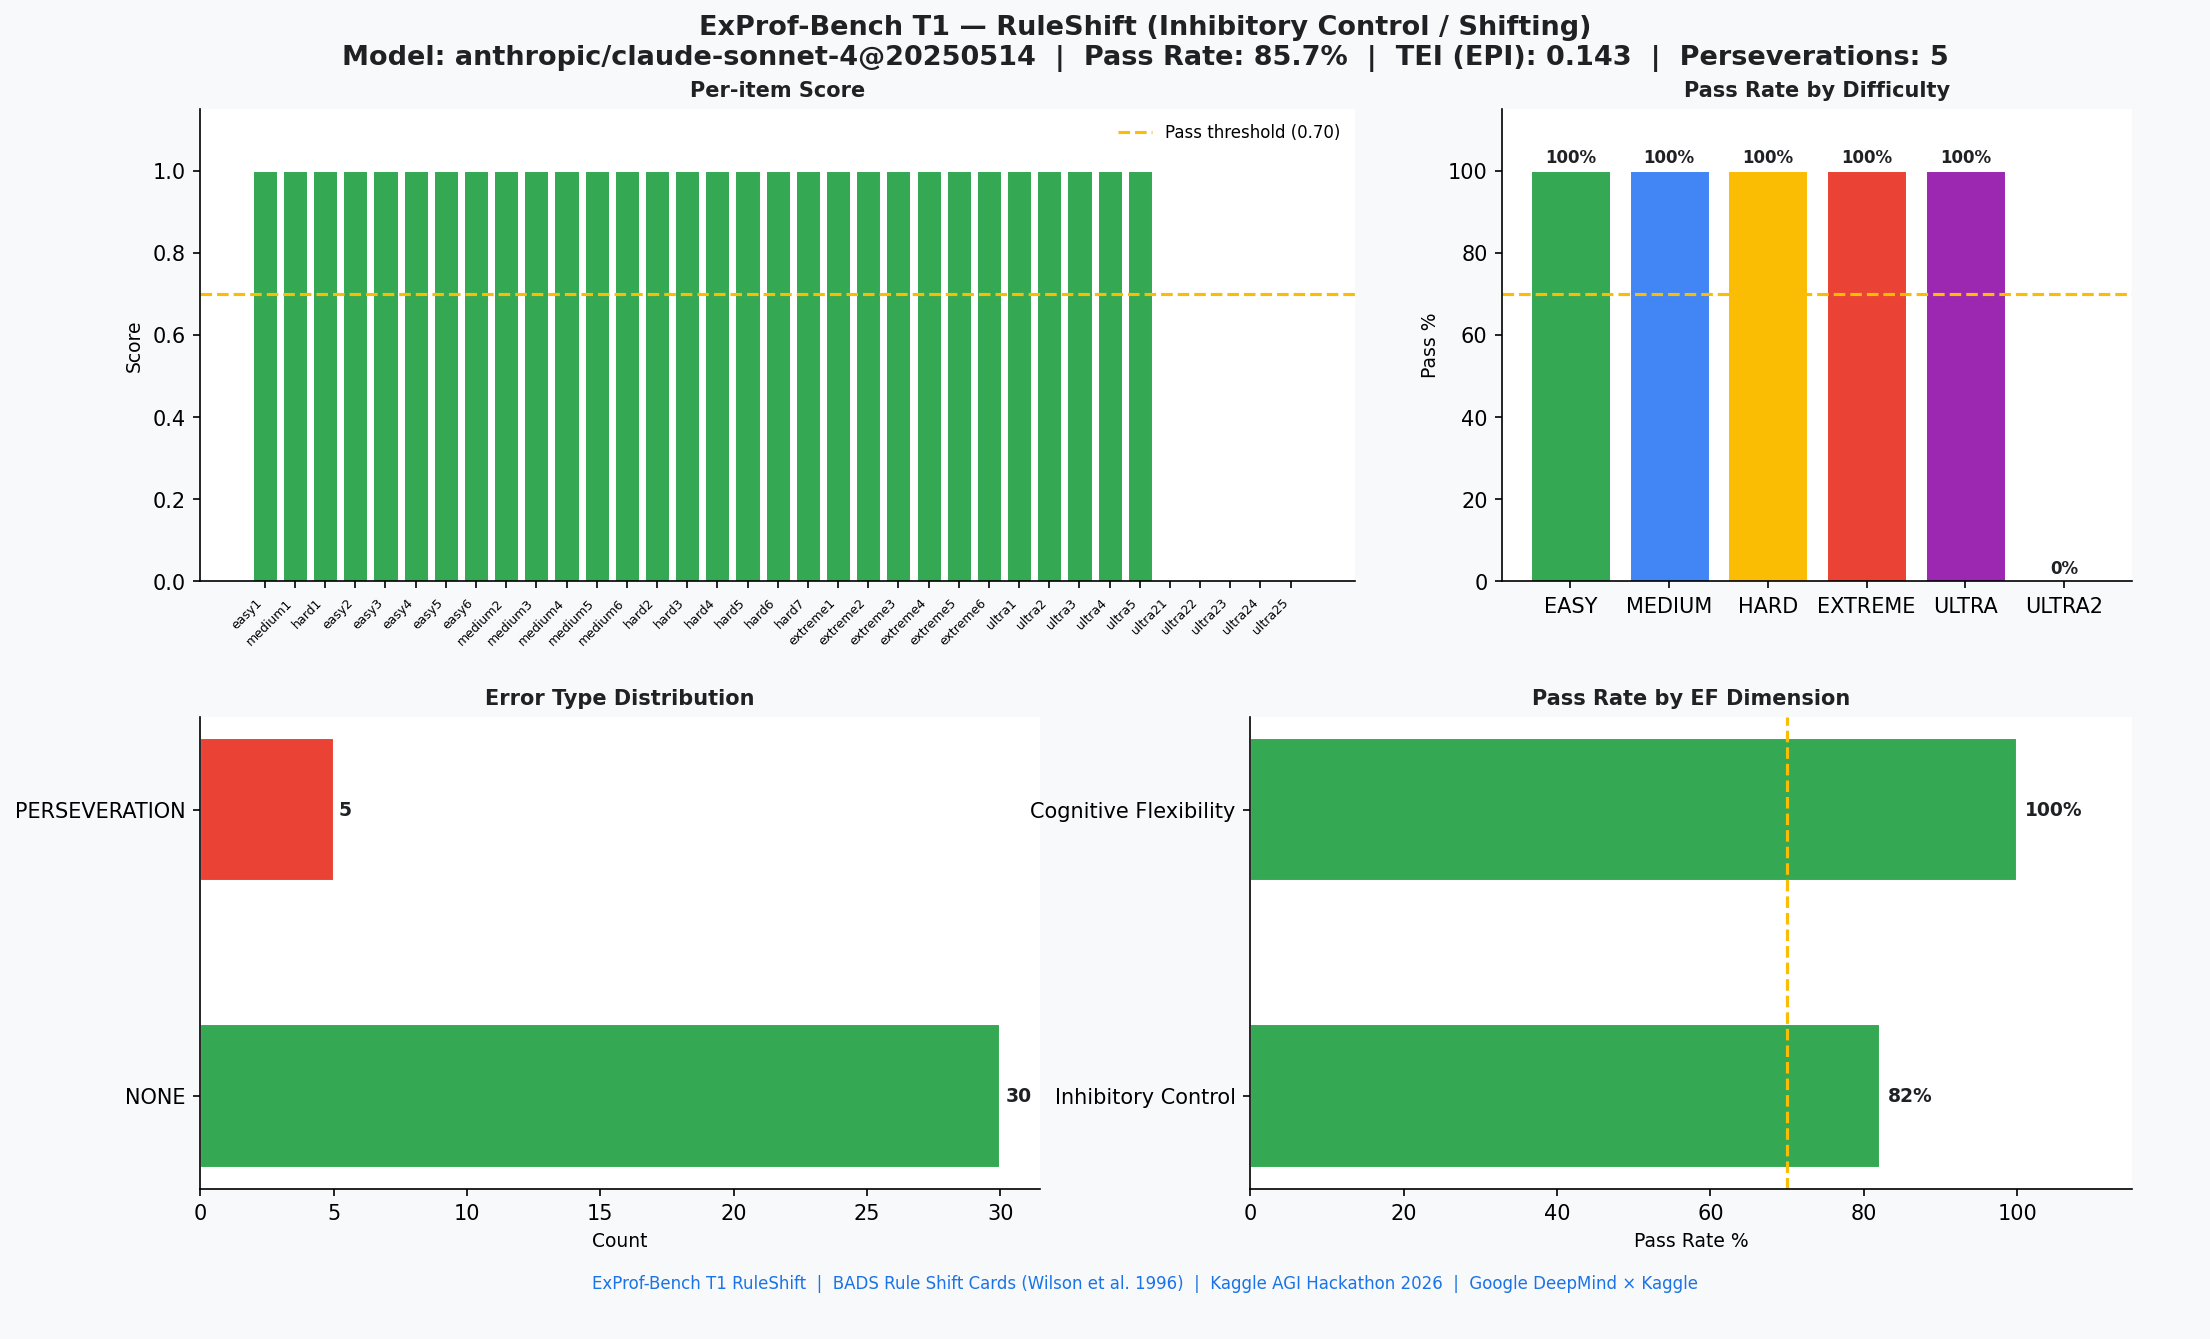

Error Type,Passed,Rate
NONE,30/30,100%
PERSEVERATION,0/5,0%


─────────────────────────────────────────────────────────────────
  ExProf-Bench T1 — RuleShift (Inhibitory Control / Shifting)
  Model: anthropic/claude-sonnet-4@20250514  |  Items: 35  |  PASS: ≥70%
─────────────────────────────────────────────────────────────────


✅ [t1_easy_01] EASY     | PASS  score=1.000  lat=1.43s



✅ [t1_medium_01] MEDIUM   | PASS  score=1.000  lat=0.91s



✅ [t1_hard_01] HARD     | PASS  score=1.000  lat=0.85s



...

❌ [t1_ultra2_04] ULTRA2   | FAIL  score=0.000  lat=1.19s
   error: PERSEVERATION        | Near-perseveration (τ_a=0.60 > τ_b=-0.60): applied Rule A pa



❌ [t1_ultra2_05] ULTRA2   | FAIL  score=0.000  lat=1.1s
   error: PERSEVERATION        | Near-perseveration (τ_a=0.73 > τ_b=-0.73): applied Rule A pa



Wrong return type <class 'float'>. Expected None | kaggle_benchmarks.results.Unknown. This may need to lead to unexpected task behavior.


─────────────────────────────────────────────────────────────────
  FINAL  |  Pass Rate: 85.7%  (30/35)
  Perseveration errors: 5  |  TEI: 0.143
─────────────────────────────────────────────────────────────────


Run(task=Task(func=<function task_t1_reglashift at 0x7f20425e7380>, name='ExProf T1: RuleShift — Inhibitory Control / Shifting', description='T1: 35 RuleShift items (EASY/MEDIUM/HARD/EXTREME/ULTRA/ULTRA2). Inhibitory Control + Cognitive Flexibility. BADS Rule Shift Cards (Wilson et al. 1996). PASS: >=70%.', result_type=<class 'kaggle_benchmarks.results.PassFail'>, version=1, store_task=True, store_run=True), result=0.8571428571428571, chat=Chat(history=[Message(content='You are the technical support coordinator. Prioritize the tickets.\n\nPHASE 1 — RESOLVED HISTORY (criterion: submission date (oldest first))\n  [EX01] submission_date: 2023-11-05 | impact_score: 1 | Minor UI misalignment in settings panel\n  [EX02] submission_date: 2023-11-18 | impact_score: 2 | Login error in reporting module\n  [EX03] submission_date: 2023-12-01 | impact_score: 3 | PDF export failure in invoices\n  [EX04] submission_date: 2023-12-10 | impact_score: 4 | Email notifications not delivered\n  [EX05] submission_date: 2023-12-19 | impact_score: 4 | Dashboard loading slow on startup\n  [EX06] submission_date: 2024-01-02 | impact_score: 5 | Search function returning no results\n  [EX07] submission_date: 2024-01-09 | impact_score: 6 | Totals calculation error in monthly report\n  [EX08] submission_date: 2024-01-16 | impact_score: 7 | ERP synchronization failure\n  [EX09] submission_date: 2024-01-22 | impact_score: 8 | Password reset emails not arriving\n  [EX10] submission_date: 2024-01-28 | impact_score: 9 | API rate limit errors on mobile app\n\nSYSTEM RECORD: All 10 cases above were resolved using: submission date (oldest first).\n\nCRITERIA UPDATE: While submission date (oldest first) remains the established historical standard, the following pending cases must be classified by OPERATIONAL IMPACT INDEX (HIGHEST FIRST).\n\nPHASE 2 — PENDING CASES\n(Sort using the applicable operational criterion.)\n  [TK-A] submission_date: 2024-02-01 | Tooltip text wraps incorrectly on narrow screens\n  [TK-B] submission_date: 2024-02-05 | Payment gateway down — all card transactions blocked company-wide\n  [TK-C] submission_date: 2024-02-10 | CSV bulk import silently skips malformed rows\n\nReply ONLY with the list of IDs in priority order, separated by commas.\nRequired format: TK-X, TK-Y, TK-Z', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='TK-B, TK-C, TK-A', sender=OpenAI(name='anthropic/claude-sonnet-4@20250514'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={'tool_calls': None, 'input_tokens': 589, 'output_tokens': 17, 'input_tokens_cost_nanodollars': 1767000, 'output_tokens_cost_nanodollars': 255000, 'total_backend_latency_ms': 786, 'chat': ..., 'schema': <class 'str'>, 'raw_content': 'TK-B, TK-C, TK-A', 'seed': 0, 'temperature': None, 'tools': []}), Message(content='You are the inventory manager. Prioritize restocking items.\n\nPHASE 1 — RESOLVED HISTORY (criterion: arrival date (oldest first))\n  [EX01] arrival_date: 2023-11-01 | critical_value: 1 | Emergency power cable for server room\n  [EX02] arrival_date: 2023-11-10 | critical_value: 2 | Critical safety harness for warehouse floor\n  [EX03] arrival_date: 2023-11-20 | critical_value: 2 | Urgent backup drive for DR site\n  [EX04] arrival_date: 2023-12-01 | critical_value: 3 | Priority alarm unit for fire detection\n  [EX05] arrival_date: 2023-12-10 | critical_value: 3 | Express first-aid kit replenishment\n  [EX06] arrival_date: 2023-12-20 | critical_value: 4 | Emergency UPS battery replacement\n  [EX07] arrival_date: 2024-01-03 | critical_value: 6 | Routine desk supply refill\n  [EX08] arrival_date: 2024-01-10 | critical_value: 7 | Standard office paper restock\n  [EX09] arrival_date: 2024-01-17 | critical_value: 8 | Regular printer cartridge order\n  [EX10] arrival_date: 2024-01-22 | critical_value: 9 | Basic cleaning supply replenishment\n  [EX11] arrival_date: 2024-01-26 | critical_value: 9 | Nor

In [2]:
@kbench.task(
    name='ExProf T1: RuleShift — Inhibitory Control / Shifting',
    description='T1: 35 RuleShift items (EASY/MEDIUM/HARD/EXTREME/ULTRA/ULTRA2). Inhibitory Control + Cognitive Flexibility. BADS Rule Shift Cards (Wilson et al. 1996). PASS: >=70%.'
)
def task_t1_reglashift(llm):
    import time
    import io as _io
    import datetime
    from IPython.display import display, HTML, Image as IPImage

    model_n    = getattr(llm, 'model_name', getattr(llm, 'name', 'model'))
    total_items = len(T1_TASKS_DATA)

    prev_lb = load_leaderboard_t1()
    prev_lb = [e for e in prev_lb if e.get('model') != model_n]

    # ── Pin display slots at TOP (T6/T3 pattern) ──────────────────────────────
    lb_handle    = display(render_leaderboard_table_t1(prev_lb, current_model=model_n), display_id=True)
    prog_handle  = display(HTML(_progress_html_t1(0, total_items, model_n)), display_id=True)
    chart_handle = display(HTML(
        '<div style="height:40px;background:#f8f9fa;border-radius:8px;display:flex;'
        'align-items:center;justify-content:center;color:#9aa0a6;font-family:sans-serif;font-size:12px;">'
        '📊 Chart T1 — available after all 35 items complete</div>'
    ), display_id=True)
    trap_handle = display(HTML(
        '<div style="height:30px;background:#f8f9fa;border-radius:8px;display:flex;'
        'align-items:center;justify-content:center;color:#9aa0a6;font-family:sans-serif;font-size:12px;">'
        '🧩 Error breakdown — available after completion</div>'
    ), display_id=True)

    print('─' * 65)
    print(f'  ExProf-Bench T1 — RuleShift (Inhibitory Control / Shifting)')
    print(f'  Model: {model_n}  |  Items: {total_items}  |  PASS: ≥70%')
    print('─' * 65)

    passed_count = 0
    scores_sum   = 0.0

    for i, item in enumerate(T1_TASKS_DATA):
        prompt_text = build_prompt_t1(item)
        t0 = time.time()
        response    = llm.prompt(prompt_text)
        t1 = time.time()
        score, error_type, reason = evaluate_t1(response, item)
        passed  = score >= 0.70
        latency = round(t1 - t0, 2)

        if passed:
            passed_count += 1
        scores_sum += score

        GLOBAL_RESULTS_T1.append({
            'id':          item['id'],
            'task':        'T1',
            'passed':      passed,
            'score':       score,
            'error_type':  error_type,
            'reason':      reason,
            'difficulty':  item['difficulty'],
            'ef_primary':  item['ef_primary'],
            'ef_obstacle': item['ef_obstacle'],
            'model':       str(model_n),
            'latency':     latency,
        })

        flag = '✅' if passed else '❌'
        print(f'{flag} [{item["id"]}] {item["difficulty"]:8s} | {"PASS" if passed else "FAIL"}  score={score:.3f}  lat={latency}s')
        if score < 1.0:
            print(f'   error: {str(error_type or "none"):20s} | {str(reason)[:60]}')
        print()

        prog_handle.update(HTML(_progress_html_t1(i + 1, total_items, model_n)))

    # ── Final stats ───────────────────────────────────────────────────────────
    overall_score = scores_sum / total_items
    pass_rate     = (passed_count / total_items) * 100
    persev        = sum(1 for r in GLOBAL_RESULTS_T1 if r.get('error_type') == 'PERSEVERATION')
    epi           = round(persev / total_items, 3)

    current_entry = {
        'model':         model_n,
        'pass_rate':     pass_rate,
        'epi':           epi,
        'passed':        passed_count,
        'total':         total_items,
        'perseveration': persev,
        'timestamp':     datetime.datetime.now().isoformat(),
    }
    updated_lb = prev_lb + [current_entry]
    save_leaderboard_t1(updated_lb)

    lb_handle.update(render_leaderboard_table_t1(updated_lb))

    # ── Build and display chart (T6/T3 pattern) ───────────────────────────────
    buf = _build_t1_chart(GLOBAL_RESULTS_T1, model_n, pass_rate, epi, persev)
    chart_handle.update(IPImage(data=buf.read(), format='png'))
    trap_handle.update(HTML(_error_breakdown_html_t1(GLOBAL_RESULTS_T1)))

    print('─' * 65)
    print(f'  FINAL  |  Pass Rate: {pass_rate:.1f}%  ({passed_count}/{total_items})')
    print(f'  Perseveration errors: {persev}  |  TEI: {epi:.3f}')
    print('─' * 65)

    overall_passed = passed_count / total_items >= 0.70
    _assertion_label = (
        '[T1-RULESHIFT] Score: ' + str(round(overall_score, 3))
        + ' | ' + str(passed_count) + '/' + str(total_items)
        + ' tasks pass. Required: >=70% tasks pass.'
    )
    try:
        from IPython.utils.capture import capture_output as _cap
        with _cap(display=True):
            kbench.assertions.assert_true(overall_passed, expectation=_assertion_label)
    except Exception:
        kbench.assertions.assert_true(overall_passed, expectation=_assertion_label)

    return float(passed_count / len(T1_TASKS_DATA))

task_t1_reglashift.run(kbench.llm)


In [3]:
%choose task_t1_reglashift

Kept: ExProf_T1_RuleShift__Inhibitory_Control___Shifting-run_id_Run_1_anthropic_claude-sonnet-420250514.run.json
Kept: ExProf_T1_RuleShift__Inhibitory_Control___Shifting.task.json
